# K04_02 Lineare Regression Übung

Letzter Update am 23. Mai 2026

**Dozentenversion**

Diese Fassung enthält kurze Musterlösungen und didaktische Hinweise für den Einsatz in der Vorlesung.

# Übung: Erstelle ein lineares Regressions-Modell

## 0. Die Übungs-Daten vorbereiten

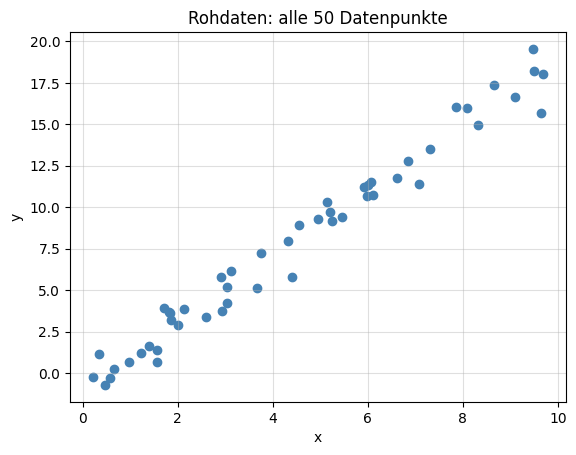

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

# Reproduzierbarer Zufallszahlengenerator
rng = np.random.RandomState(42)

# 50 unabhängige Stichproben aus einer Gleichverteilung im Intervall (0, 10)
x = 10 * rng.rand(50)

# Zielvariable gemäß dem linearen Modell y = 2x - 1 + ε
# Steigung 2, y-Achsenabschnitt -1, ε = normalverteiltes Rauschen
y = 2 * x - 1 + rng.randn(50)

plt.scatter(x, y, color='steelblue')
plt.title("Rohdaten: alle 50 Datenpunkte")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.4)
plt.show()


## Train/Test-Split

Bevor wir das Modell trainieren, teilen wir die Daten in **Trainings-** und **Testdaten** auf.

- Das Modell lernt **nur** auf den Trainingsdaten.
- Die Testdaten werden erst am Ende zur Bewertung verwendet – das Modell sieht sie beim Training nicht.

> **Hinweis:** `stratify` ist hier nicht verfügbar, weil `y` kontinuierlich ist
> (kein Klassifikationsproblem). `stratify` wird nur bei Klassifikation eingesetzt.


In [8]:
# Feature-Matrix X: scikit-learn erwartet ein 2D-Array der Form (n_samples, n_features)
# reshape(-1, 1): aus (50,) wird (50, 1) – -1 bedeutet 'Anzahl Zeilen automatisch berechnen'
X = x.reshape(-1, 1)

# 80% Trainingsdaten, 20% Testdaten
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
    # stratify nicht verfügbar bei Regression (y ist kontinuierlich)
)

print(f"Gesamtdaten:    {len(X)} Datenpunkte")
print(f"Trainingsdaten: {len(X_train)} Datenpunkte (80%)")
print(f"Testdaten:      {len(X_test)} Datenpunkte (20%)")
print(f"Shape X_train:  {X_train.shape}  ← (n_samples, n_features)")


Gesamtdaten:    50 Datenpunkte
Trainingsdaten: 40 Datenpunkte (80%)
Testdaten:      10 Datenpunkte (20%)
Shape X_train:  (40, 1)  ← (n_samples, n_features)


## 1. Eine Modellklasse auswählen und initialisieren

In [9]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

## 2. Feature-Matrix und Zielvektor

Die Feature-Matrix `X_train` und der Zielvektor `y_train` wurden bereits durch den
Train/Test-Split erstellt. Hier prüfen wir die Shapes zur Kontrolle:

- `X_train`: Form `(n_samples, n_features)` – bei einem Merkmal also `(40, 1)`
- `y_train`: Form `(n_samples,)` – eindimensional


In [10]:
# Shapes der Trainings-Arrays zur Kontrolle
print(f"X_train.shape: {X_train.shape}  ← {X_train.shape[0]} Samples, {X_train.shape[1]} Feature")
print(f"y_train.shape: {y_train.shape}  ← {y_train.shape[0]} Zielwerte")
print(f"X_test.shape:  {X_test.shape}   ← {X_test.shape[0]} Test-Samples (werden noch nicht verwendet)")


X_train.shape: (40, 1)  ← 40 Samples, 1 Feature
y_train.shape: (40,)  ← 40 Zielwerte
X_test.shape:  (10, 1)   ← 10 Test-Samples (werden noch nicht verwendet)


## 3. Das Modell trainieren anhand der Trainingsdaten

In [11]:
model.fit(X_train, y_train)   # nur Trainingsdaten – Testdaten bleiben unberührt

# Koeffizienten
a = model.coef_[0]
b = model.intercept_

print(f"Gelerntes Modell: y = {a:.4f} * x + {b:.4f}")
print()
print(f"Wahres Modell:    y = 2.0000 * x + (-1.0000)")
print("Die Ergebnisse liegen sehr nahe an den wahren Werten – das Modell hat gut gelernt.")


Gelerntes Modell: y = 1.9724 * x + -0.8763

Wahres Modell:    y = 2.0000 * x + (-1.0000)
Die Ergebnisse liegen sehr nahe an den wahren Werten – das Modell hat gut gelernt.


## 4. Prognose und Visualisierung

Wir erstellen ein feines Raster von x-Werten (`x_linspace`), um eine glatte
Regressionslinie zu zeichnen. Das ist **nicht** dasselbe wie die Testdaten –
es dient nur der Visualisierung.

Im Plot sehen wir:
- 🔵 **Blaue Punkte** = Trainingsdaten (das Modell hat darauf gelernt)
- 🟠 **Orange Rauten** = Testdaten (das Modell hat sie noch nie gesehen)
- 🔴 **Rote Linie** = Regressionsgerade


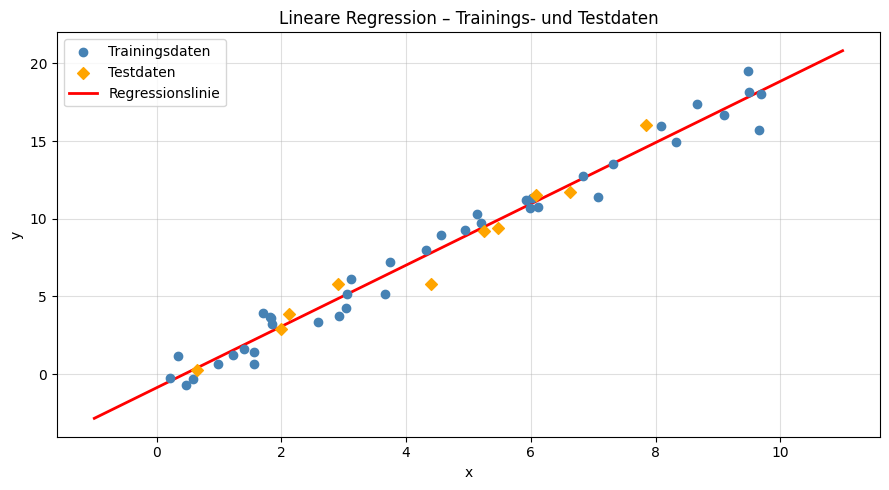

In [6]:
# Feines Raster für die Regressionslinie (nur zur Visualisierung, kein echter Test-Split)
x_linspace = np.linspace(-1, 11, 200)
X_linspace = x_linspace[:, np.newaxis]   # (200, 1) für scikit-learn

y_prognose = model.predict(X_linspace)

# Plot: Trainings- und Testpunkte getrennt darstellen
plt.figure(figsize=(9, 5))
plt.scatter(X_train, y_train, color='steelblue', label='Trainingsdaten', zorder=3)
plt.scatter(X_test,  y_test,  color='orange',    label='Testdaten',
            marker='D', zorder=3)
plt.plot(x_linspace, y_prognose, color='red', linewidth=2, label='Regressionslinie')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Lineare Regression – Trainings- und Testdaten")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


## 5. Das Bestimmtheitsmaß R² berechnen

R² misst, wie gut das Modell die Streuung der Zielwerte erklärt.
Wir berechnen R² auf den **Testdaten** – das ist die ehrliche Schätzung,
wie gut das Modell auf neuen, ungesehenen Daten funktioniert.

| R²-Wert | Interpretation |
|:---:|---|
| 1.0 | Modell erklärt die Daten perfekt |
| 0.8 | Modell erklärt 80 % der Streuung |
| 0.0 | Nicht besser als der Mittelwert |
| < 0 | Schlechter als der Mittelwert |


In [12]:
from sklearn.metrics import r2_score

# Vorhersage auf den TESTDATEN – diese hat das Modell beim Training nicht gesehen
y_pred_test = model.predict(X_test)
r2_test = r2_score(y_test, y_pred_test)
print(f"R² auf Testdaten:      {r2_test:.4f}  ← die entscheidende Kennzahl")

# Zum Vergleich: R² auf Trainingsdaten (fast immer höher)
y_pred_train = model.predict(X_train)
r2_train = r2_score(y_train, y_pred_train)
print(f"R² auf Trainingsdaten: {r2_train:.4f}  ← immer etwas optimistischer")

print()
print("Merksatz: R² auf Trainingsdaten lügt – R² auf Testdaten sagt die Wahrheit.")


R² auf Testdaten:      0.9613  ← die entscheidende Kennzahl
R² auf Trainingsdaten: 0.9768  ← immer etwas optimistischer

Merksatz: R² auf Trainingsdaten lügt – R² auf Testdaten sagt die Wahrheit.


Das **Bestimmtheitsmaß R²** gibt an, wie viel Prozent der Varianz der Zielwerte
das Modell erklärt. Der Wert liegt typischerweise zwischen 0 und 1.

**Wichtig:** Der hier berechnete R²-Wert bezieht sich auf die **Testdaten**.
Ein hohes R² auf Trainingsdaten wäre wenig aussagekräftig – das Modell könnte
einfach die Daten auswendig gelernt haben (Overfitting).

In diesem Fall liegt R² auf dem Testset sehr hoch, was plausibel ist:
Die Daten wurden mit einem echten linearen Zusammenhang erzeugt (`y = 2x - 1 + ε`),
und das Modell hat diesen Zusammenhang fast exakt rekonstruiert.


## Musterlösung / didaktische Hinweise

**Mögliche Reflexionsantworten**

1. `X` ist in scikit-learn eine **Feature-Matrix** mit Form `(n_samples, n_features)`.
   Auch bei nur einem Merkmal bleibt die Eingabe zweidimensional. `reshape(-1, 1)`
   wandelt das 1D-Array in die richtige Form um.
2. Ein hoher **R²-Wert auf Testdaten** bedeutet, dass das Modell auch auf neuen,
   ungesehenen Daten gut funktioniert. Entscheidend ist immer der Test-R²,
   nicht der Train-R².
3. Ein schlechtes Modell erkennt man an einem niedrigen Test-R² oder daran,
   dass die Regressionsgerade die Punktwolke sichtbar schlecht beschreibt.
4. Ein hohes Train-R² bei deutlich niedrigerem Test-R² ist ein Zeichen
   für **Overfitting** – das Modell hat die Trainingsdaten auswendig gelernt
